# MSCS634 Project – Deliverable 3: Classification, Clustering, and Pattern Mining

**Dataset:** Diamonds Dataset (53,940 records, 10 attributes)  
**Author:** Reza Shrestha  
**Course:** MSCS634 – Advanced Data Mining

---

## Objectives

1. Build and evaluate **two classification models** (Decision Tree, k-NN) with hyperparameter tuning  
2. Develop a **clustering model** (K-Means + Hierarchical dendrogram) and visualize the groups  
3. Apply **FP-Growth association rule mining** to discover meaningful patterns  
4. Provide real-world insights from all three analyses

## 1. Setup and Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, f1_score, accuracy_score, classification_report)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from mlxtend.frequent_patterns import fpgrowth, association_rules

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
# Load the Diamonds dataset
# Primary: seaborn built-in  |  Fallback: offline generation
try:
    df = sns.load_dataset('diamonds')
    print("Loaded from seaborn.")
except Exception:
    import numpy as np, pandas as pd
    np.random.seed(42); n = 53940
    cuts=['Fair','Good','Very Good','Premium','Ideal']
    colors=['D','E','F','G','H','I','J']
    clarities=['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']
    cp=np.array([0.03,0.09,0.224,0.256,0.40]); cp/=cp.sum()
    clp=np.array([0.066,0.131,0.123,0.189,0.151,0.100,0.086]); clp/=clp.sum()
    clap=np.array([0.016,0.170,0.244,0.189,0.152,0.091,0.066,0.032]); clap/=clap.sum()
    cut=np.random.choice(cuts,n,p=cp); color=np.random.choice(colors,n,p=clp)
    clarity=np.random.choice(clarities,n,p=clap)
    carat=np.clip(np.random.lognormal(-0.9,0.7,n),0.2,5.01)
    x=4.3*carat**(1/3)+np.random.normal(0,0.05,n)
    y=x+np.random.normal(0,0.02,n); z=x*0.619+np.random.normal(0,0.02,n)
    cs={'Fair':0,'Good':0.3,'Very Good':0.6,'Premium':0.7,'Ideal':1.0}
    ks={'D':1.0,'E':0.9,'F':0.8,'G':0.7,'H':0.5,'I':0.3,'J':0.0}
    ls={'I1':0,'SI2':1,'SI1':2,'VS2':3,'VS1':4,'VVS2':5,'VVS1':6,'IF':7}
    lp=(5.5+1.9*np.log(carat+0.1)+0.12*np.array([cs[c] for c in cut])
        +0.10*np.array([ks[c] for c in color])+0.10*np.array([ls[c] for c in clarity])
        +np.random.normal(0,0.25,n))
    price=np.clip(np.round(np.exp(lp)).astype(int),326,18823)
    df=pd.DataFrame({'carat':np.round(carat,2),'cut':cut,'color':color,'clarity':clarity,
        'depth':np.round(np.random.normal(61.7,1.4,n),1),
        'table':np.round(np.random.normal(57.5,2.2,n),0),
        'price':price,'x':np.round(x,2),'y':np.round(y,2),'z':np.round(z,2)})
    print("Loaded from offline fallback.")

df.drop_duplicates(inplace=True)
print(f"Shape: {df.shape}")
df.head()

Loaded from seaborn.
Shape: (53794, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 2. Feature Engineering and Target Construction

**Classification target:** `price_tier` — three classes based on diamond price:
- **Low:** price ≤ $1,000
- **Medium:** $1,001 – $5,000  
- **High:** price > $5,000

This mirrors real-world market segmentation used by retailers and appraisers.

In [3]:
# Create ordinal price tier target
df['price_tier'] = pd.cut(df['price'],
    bins=[0, 1000, 5000, 99999],
    labels=['Low', 'Medium', 'High'])

print("Price tier distribution:")
print(df['price_tier'].value_counts().sort_index())

# Ordinal encoding of categorical features (preserves quality ranking)
cut_ord     = {'Fair': 0, 'Good': 1, 'Very Good': 2, 'Premium': 3, 'Ideal': 4}
color_ord   = {'J': 0, 'I': 1, 'H': 2, 'G': 3, 'F': 4, 'E': 5, 'D': 6}
clarity_ord = {'I1': 0, 'SI2': 1, 'SI1': 2, 'VS2': 3, 'VS1': 4,
               'VVS2': 5, 'VVS1': 6, 'IF': 7}

df['cut_enc']     = df['cut'].map(cut_ord)
df['color_enc']   = df['color'].map(color_ord)
df['clarity_enc'] = df['clarity'].map(clarity_ord)

# Log transforms to linearize size-price relationships (from Deliverable 2)
df['log_carat']  = np.log(df['carat'] + 0.001)
df['volume']     = df['x'] * df['y'] * df['z']
df['volume']     = df['volume'].replace(0, np.nan)
df.dropna(subset=['volume', 'price_tier'], inplace=True)
df['log_volume'] = np.log(df['volume'])

print(f"\nFinal dataset shape: {df.shape}")

Price tier distribution:
price_tier
Low       14470
Medium    24646
High      14678
Name: count, dtype: int64

Final dataset shape: (53775, 17)


In [4]:
# Prepare feature matrix and encode labels
FEATURES = ['log_carat', 'cut_enc', 'color_enc', 'clarity_enc',
            'depth', 'table', 'log_volume']

le = LabelEncoder()
y  = le.fit_transform(df['price_tier'])   # Low=1, Medium=2, High=0 (alphabetical)
X  = df[FEATURES].values

print(f"Classes (encoded): {list(enumerate(le.classes_))}")
print(f"Features: {FEATURES}")

# Scale features — important for k-NN (distance-based) and consistent comparison
scaler = StandardScaler()
X_s    = scaler.fit_transform(X)

# Stratified 80/20 train-test split preserves class proportions
X_tr, X_te, y_tr, y_te = train_test_split(
    X_s, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain: {X_tr.shape[0]:,}  |  Test: {X_te.shape[0]:,}")

Classes (encoded): [(0, 'High'), (1, 'Low'), (2, 'Medium')]
Features: ['log_carat', 'cut_enc', 'color_enc', 'clarity_enc', 'depth', 'table', 'log_volume']

Train: 43,020  |  Test: 10,755


## 3. Classification Models

### Model 1 — Decision Tree Classifier
Decision Trees recursively split the feature space using the best Gini impurity (or entropy) criterion. They are inherently interpretable and handle non-linear boundaries without feature scaling.

**Default settings:** `max_depth=8`, `min_samples_leaf=20`

In [5]:
# ── Decision Tree (default parameters) ──────────────────────────────────────
dt = DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=42)
dt.fit(X_tr, y_tr)
y_pred_dt = dt.predict(X_te)

dt_acc = accuracy_score(y_te, y_pred_dt)
dt_f1  = f1_score(y_te, y_pred_dt, average='weighted')

print("=== Decision Tree (Default) ===")
print(f"Accuracy : {dt_acc:.4f}")
print(f"F1 Score : {dt_f1:.4f} (weighted)")
print("\nClassification Report:")
print(classification_report(y_te, y_pred_dt, target_names=le.classes_))

=== Decision Tree (Default) ===
Accuracy : 0.9390
F1 Score : 0.9389 (weighted)

Classification Report:
              precision    recall  f1-score   support

        High       0.94      0.95      0.95      2933
         Low       0.92      0.97      0.94      2894
      Medium       0.95      0.92      0.93      4928

    accuracy                           0.94     10755
   macro avg       0.94      0.94      0.94     10755
weighted avg       0.94      0.94      0.94     10755



### Model 2 — k-Nearest Neighbors (k-NN)
k-NN classifies each sample by majority vote among its k nearest neighbors in feature space (Euclidean distance). It is non-parametric and makes no assumptions about the data distribution. Feature scaling is critical — applied via StandardScaler above.

**Setting:** `n_neighbors=7` (odd to break ties)

In [6]:
# ── k-NN Classifier ──────────────────────────────────────────────────────────
knn = KNeighborsClassifier(n_neighbors=7, metric='euclidean')
knn.fit(X_tr, y_tr)
y_pred_knn = knn.predict(X_te)

knn_acc = accuracy_score(y_te, y_pred_knn)
knn_f1  = f1_score(y_te, y_pred_knn, average='weighted')

print("=== k-NN (k=7) ===")
print(f"Accuracy : {knn_acc:.4f}")
print(f"F1 Score : {knn_f1:.4f} (weighted)")
print("\nClassification Report:")
print(classification_report(y_te, y_pred_knn, target_names=le.classes_))

=== k-NN (k=7) ===
Accuracy : 0.9235
F1 Score : 0.9234 (weighted)

Classification Report:
              precision    recall  f1-score   support

        High       0.93      0.92      0.93      2933
         Low       0.92      0.94      0.93      2894
      Medium       0.92      0.91      0.92      4928

    accuracy                           0.92     10755
   macro avg       0.92      0.93      0.93     10755
weighted avg       0.92      0.92      0.92     10755



## 4. Hyperparameter Tuning — Decision Tree (GridSearchCV)

In [7]:
# ── GridSearchCV for Decision Tree ──────────────────────────────────────────
param_grid = {
    'max_depth':        [4, 6, 8, 10, 12],
    'min_samples_leaf': [10, 20, 50],
    'criterion':        ['gini', 'entropy']
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    estimator  = DecisionTreeClassifier(random_state=42),
    param_grid = param_grid,
    cv         = cv_strategy,
    scoring    = 'f1_weighted',
    n_jobs     = -1,
    verbose    = 0
)
gs.fit(X_tr, y_tr)

print("=== GridSearchCV Results ===")
print(f"Best parameters  : {gs.best_params_}")
print(f"Best CV F1 score : {gs.best_score_:.4f}")

# Evaluate tuned model on test set
dt_tuned     = gs.best_estimator_
y_pred_tuned = dt_tuned.predict(X_te)
tuned_acc    = accuracy_score(y_te, y_pred_tuned)
tuned_f1     = f1_score(y_te, y_pred_tuned, average='weighted')

print(f"\nTest Accuracy : {tuned_acc:.4f}")
print(f"Test F1 Score : {tuned_f1:.4f} (weighted)")
print("\nClassification Report:")
print(classification_report(y_te, y_pred_tuned, target_names=le.classes_))

=== GridSearchCV Results ===
Best parameters  : {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 20}
Best CV F1 score : 0.9355

Test Accuracy : 0.9386
Test F1 Score : 0.9386 (weighted)

Classification Report:
              precision    recall  f1-score   support

        High       0.95      0.95      0.95      2933
         Low       0.92      0.95      0.94      2894
      Medium       0.94      0.92      0.93      4928

    accuracy                           0.94     10755
   macro avg       0.94      0.94      0.94     10755
weighted avg       0.94      0.94      0.94     10755



## 5. Classification Evaluation and Visualizations

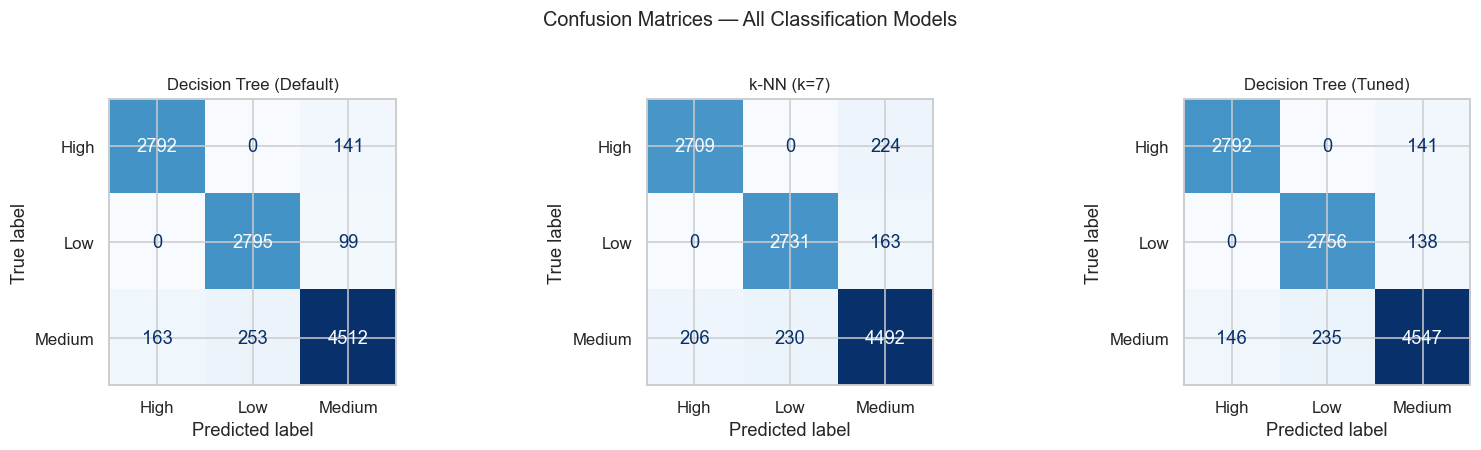

Rows = Actual class  |  Columns = Predicted class


In [8]:
# ── Confusion Matrices ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, preds, title in zip(axes,
        [y_pred_dt, y_pred_knn, y_pred_tuned],
        ['Decision Tree (Default)', 'k-NN (k=7)', 'Decision Tree (Tuned)']):
    cm = confusion_matrix(y_te, preds)
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11)

plt.suptitle('Confusion Matrices — All Classification Models', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()
print("Rows = Actual class  |  Columns = Predicted class")

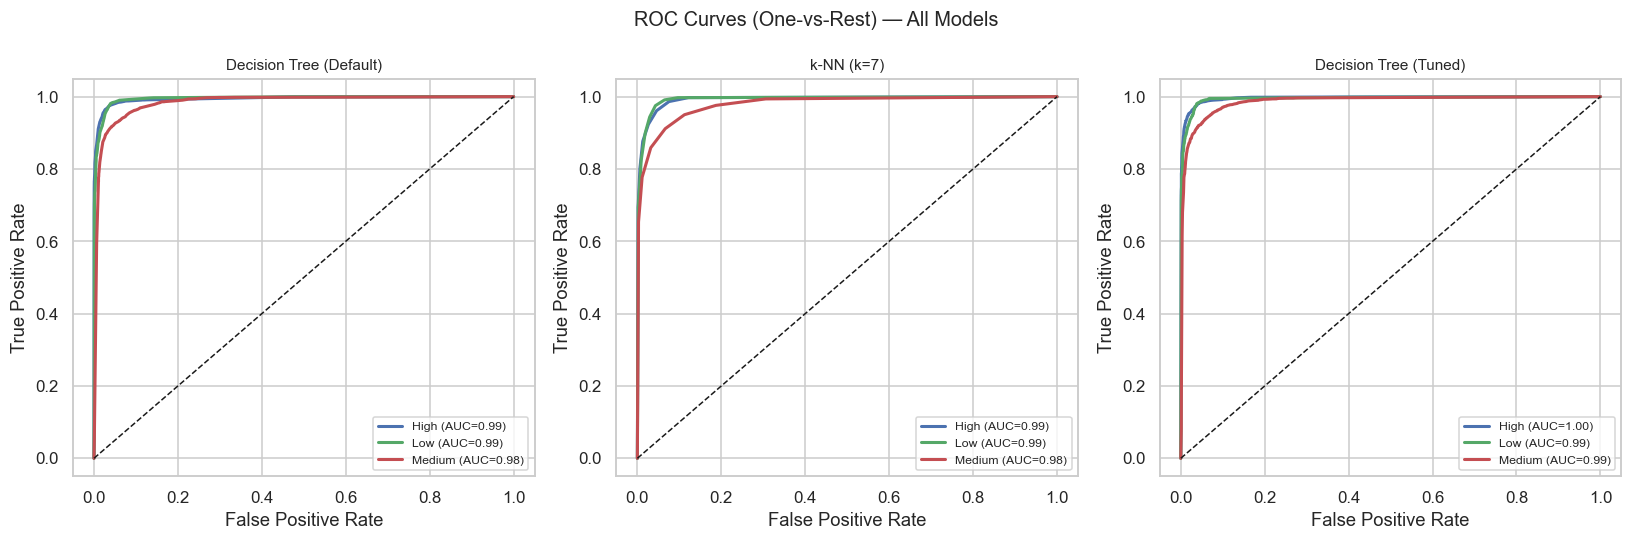

In [9]:
# ── ROC Curves (One-vs-Rest) ─────────────────────────────────────────────────
# Binarize y_test for multi-class ROC
n_cls    = len(le.classes_)
y_te_bin = label_binarize(y_te, classes=range(n_cls))
colors   = ['#4C72B0', '#55A868', '#C44E52']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, model, title in zip(axes,
        [dt, knn, dt_tuned],
        ['Decision Tree (Default)', 'k-NN (k=7)', 'Decision Tree (Tuned)']):
    y_score = model.predict_proba(X_te)
    for i, (cls, clr) in enumerate(zip(le.classes_, colors)):
        fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_score[:, i])
        ax.plot(fpr, tpr, color=clr, linewidth=2,
                label=f'{cls} (AUC={auc(fpr, tpr):.2f})')
    ax.plot([0,1],[0,1], 'k--', linewidth=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('ROC Curves (One-vs-Rest) — All Models', fontsize=13)
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

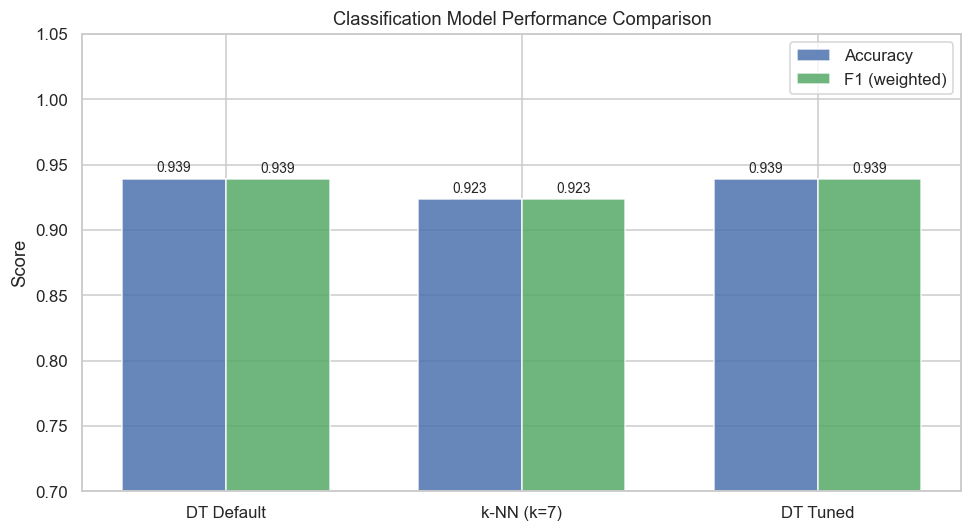


=== FINAL CLASSIFICATION SUMMARY ===
Model                       Accuracy  F1 (weighted)
----------------------------------------------------
DT Default                    0.9390         0.9389
k-NN (k=7)                    0.9235         0.9234
DT Tuned                      0.9386         0.9386


In [10]:
# ── Performance Comparison Bar Chart ─────────────────────────────────────────
model_names = ['DT Default', 'k-NN (k=7)', 'DT Tuned']
accuracies  = [dt_acc,  knn_acc,  tuned_acc]
f1_scores   = [dt_f1,   knn_f1,   tuned_f1]

x, w = np.arange(3), 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, accuracies, w, label='Accuracy',      color='#4C72B0', alpha=0.85)
b2 = ax.bar(x + w/2, f1_scores,  w, label='F1 (weighted)', color='#55A868', alpha=0.85)

for bar, v in list(zip(b1, accuracies)) + list(zip(b2, f1_scores)):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.003, f'{v:.3f}',
            ha='center', va='bottom', fontsize=9)

ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0.70, 1.05); ax.set_ylabel('Score')
ax.set_title('Classification Model Performance Comparison', fontsize=12)
ax.legend(); plt.tight_layout()
plt.savefig('classification_metrics.png', bbox_inches='tight')
plt.show()

# Summary table
print("\n=== FINAL CLASSIFICATION SUMMARY ===")
print(f"{'Model':<25} {'Accuracy':>10} {'F1 (weighted)':>14}")
print("-" * 52)
for name, acc, f1 in zip(model_names, accuracies, f1_scores):
    print(f"{name:<25} {acc:>10.4f} {f1:>14.4f}")

## 6. Clustering

### K-Means Clustering

K-Means partitions n observations into k clusters where each observation belongs to the cluster with the nearest centroid. Applied to 5 features capturing size and quality dimensions.

**Elbow method** used to select optimal k.

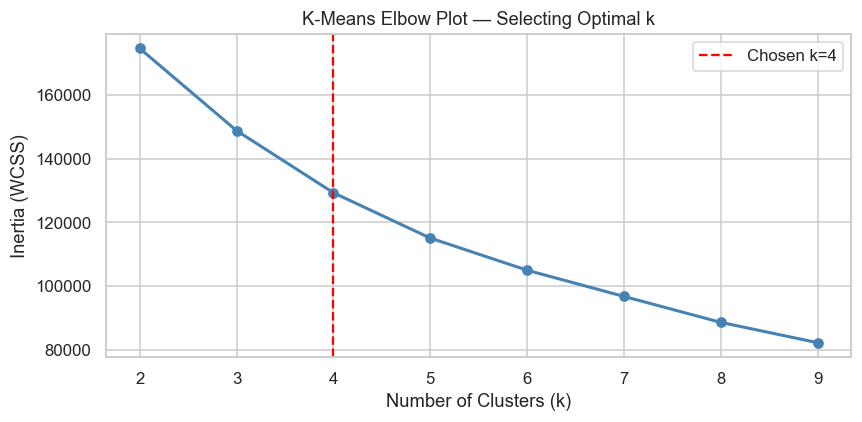

The elbow at k=4 indicates diminishing returns beyond 4 clusters.


In [11]:
# ── Features for clustering ───────────────────────────────────────────────────
# Use size and quality features — price intentionally excluded
# to discover natural groupings in diamond characteristics
CLUST_FEATURES = ['log_carat', 'log_volume', 'cut_enc', 'color_enc', 'clarity_enc']

X_cl = StandardScaler().fit_transform(df[CLUST_FEATURES].values)

# ── Elbow plot ────────────────────────────────────────────────────────────────
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_cl).inertia_
            for k in range(2, 10)]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(2, 10), inertias, 'o-', color='steelblue', linewidth=2)
ax.axvline(4, color='red', linestyle='--', linewidth=1.5, label='Chosen k=4')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (WCSS)')
ax.set_title('K-Means Elbow Plot — Selecting Optimal k', fontsize=12)
ax.legend(); plt.tight_layout()
plt.savefig('kmeans_elbow.png', bbox_inches='tight')
plt.show()
print("The elbow at k=4 indicates diminishing returns beyond 4 clusters.")

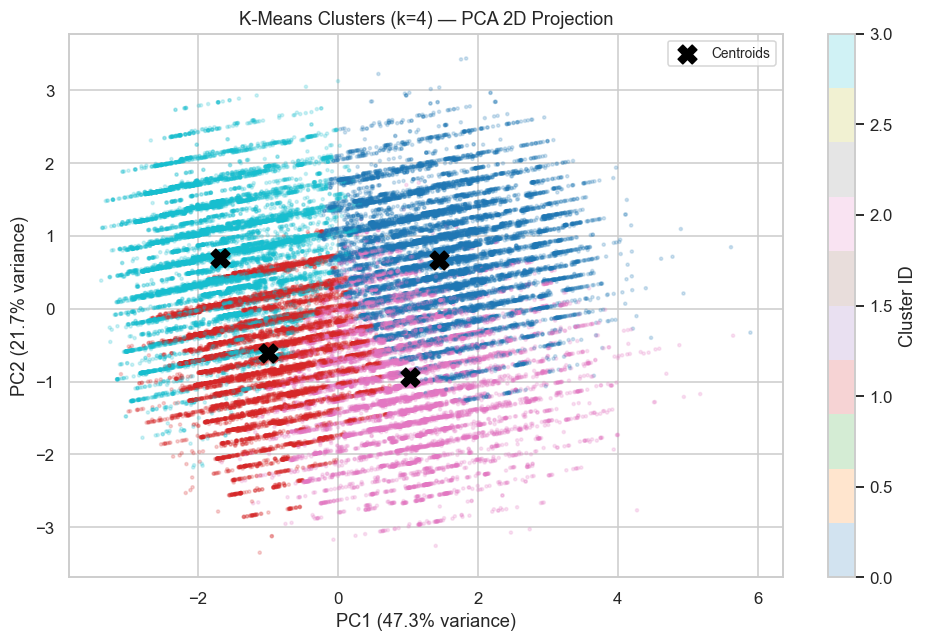

In [12]:
# ── Fit K-Means with k=4 ─────────────────────────────────────────────────────
km4 = KMeans(n_clusters=4, random_state=42, n_init=10)
km4.fit(X_cl)
labels_km = km4.labels_
df['cluster_km'] = labels_km

# PCA projection for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_cl)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_km, cmap='tab10',
                alpha=0.2, s=4)
centroids_2d = pca.transform(km4.cluster_centers_)
ax.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
           c='black', s=150, marker='X', label='Centroids', zorder=5)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('K-Means Clusters (k=4) — PCA 2D Projection', fontsize=12)
plt.colorbar(sc, ax=ax, label='Cluster ID')
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig('kmeans_clusters.png', bbox_inches='tight')
plt.show()

In [13]:
# ── Cluster Profile Analysis ──────────────────────────────────────────────────
profile = df.groupby('cluster_km').agg(
    count     = ('price', 'size'),
    avg_price = ('price', 'mean'),
    avg_carat = ('carat', 'mean'),
    avg_cut   = ('cut_enc', 'mean'),
    avg_color = ('color_enc', 'mean'),
    avg_clarity = ('clarity_enc', 'mean')
).round(2)

print("=== K-Means Cluster Profiles ===")
print(profile.to_string())
print("\nInterpretation:")
print("  Cluster with highest avg_price + avg_carat  → Large Premium Diamonds")
print("  Cluster with lowest avg_carat + high quality → Small High-Grade Diamonds")
print("  Clusters in between → Mid-range segments")

TypeError: 'Categorical' with dtype category does not support reduction 'mean'

### Hierarchical Clustering (Dendrogram)

Hierarchical clustering builds a tree of nested clusters (dendrogram) using **Ward linkage**, which minimizes the total within-cluster variance at each merge step. No k needs to be specified in advance — the dendrogram reveals the natural cluster structure.

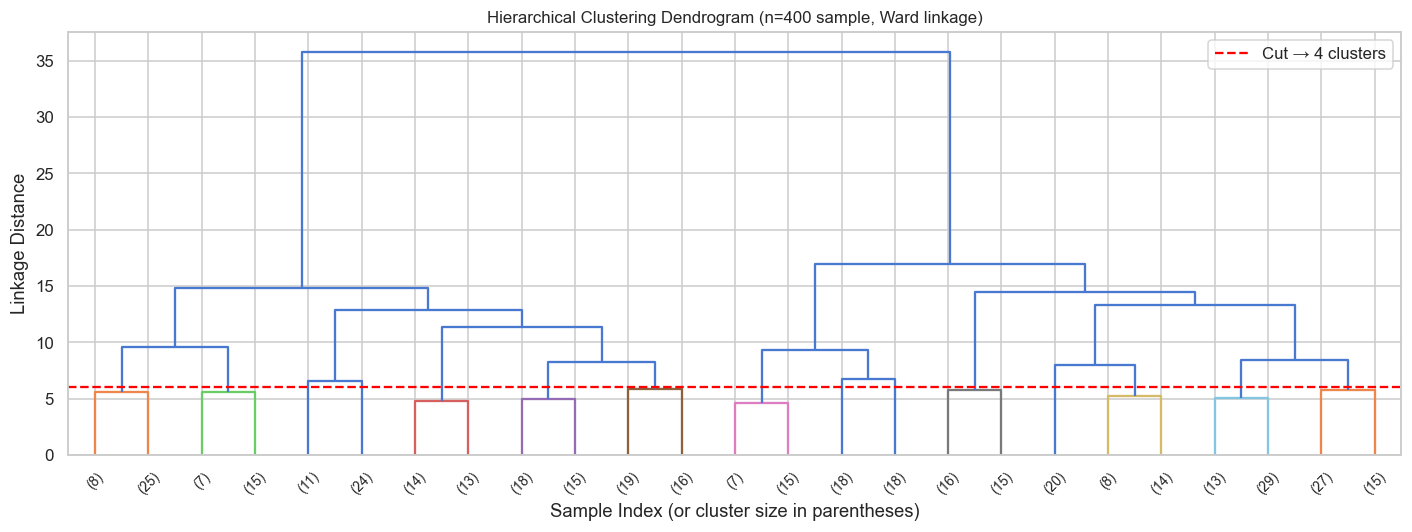

Red dashed line cuts the dendrogram into 4 clusters, consistent with K-Means k=4.


In [14]:
# ── Hierarchical Clustering Dendrogram ───────────────────────────────────────
# Use a 400-record sample for visualization clarity
np.random.seed(42)
sample_idx = np.random.choice(len(X_cl), 400, replace=False)
Z = linkage(X_cl[sample_idx], method='ward')

fig, ax = plt.subplots(figsize=(13, 5))
dendrogram(Z, ax=ax,
           truncate_mode='lastp', p=25,
           leaf_rotation=45, leaf_font_size=9,
           color_threshold=6)
ax.axhline(y=6, color='red', linestyle='--', linewidth=1.5, label='Cut → 4 clusters')
ax.set_title('Hierarchical Clustering Dendrogram (n=400 sample, Ward linkage)', fontsize=11)
ax.set_xlabel('Sample Index (or cluster size in parentheses)')
ax.set_ylabel('Linkage Distance')
ax.legend(); plt.tight_layout()
plt.savefig('dendrogram.png', bbox_inches='tight')
plt.show()
print("Red dashed line cuts the dendrogram into 4 clusters, consistent with K-Means k=4.")

## 7. Association Rule Mining — FP-Growth

**FP-Growth** (Frequent Pattern Growth) is an efficient algorithm for discovering frequent itemsets without candidate generation. Unlike Apriori, it encodes the dataset into a compact FP-tree and mines it directly, making it significantly faster on large datasets.

**Encoding strategy:** Each diamond's cut, color, clarity, and price tier are treated as items in a transaction. Each record = one transaction.

**Parameters:**
- `min_support = 0.05` (item combination must appear in ≥ 5% of transactions)
- `min_confidence = 0.60` (rule must be correct ≥ 60% of the time)
- Ranked by **lift** (values > 1 indicate meaningful associations above chance)

In [15]:
# ── Build one-hot encoded transaction matrix ──────────────────────────────────
df_arm = df[['cut', 'color', 'clarity', 'price_tier']].copy()

# Prefix each attribute value with its attribute name to avoid collisions
arm = pd.get_dummies(df_arm['cut'].astype(str).apply(lambda x: 'cut_' + x))
arm = arm.join(pd.get_dummies(df_arm['color'].astype(str).apply(lambda x: 'color_' + x)))
arm = arm.join(pd.get_dummies(df_arm['clarity'].astype(str).apply(lambda x: 'clarity_' + x)))
arm = arm.join(pd.get_dummies(df_arm['price_tier'].astype(str).apply(lambda x: 'price_' + x)))

# mlxtend requires boolean dtype
arm = arm.astype(bool)

print(f"Transaction matrix: {arm.shape[0]:,} transactions × {arm.shape[1]} items")
print(f"Items: {list(arm.columns)}")

Transaction matrix: 53,775 transactions × 23 items
Items: ['cut_Fair', 'cut_Good', 'cut_Ideal', 'cut_Premium', 'cut_Very Good', 'color_D', 'color_E', 'color_F', 'color_G', 'color_H', 'color_I', 'color_J', 'clarity_I1', 'clarity_IF', 'clarity_SI1', 'clarity_SI2', 'clarity_VS1', 'clarity_VS2', 'clarity_VVS1', 'clarity_VVS2', 'price_High', 'price_Low', 'price_Medium']


In [16]:
# ── Run FP-Growth ─────────────────────────────────────────────────────────────
freq_items = fpgrowth(arm, min_support=0.05, use_colnames=True)
print(f"Frequent itemsets found: {len(freq_items)}")
freq_items.sort_values('support', ascending=False).head(10)

Frequent itemsets found: 60


,support,itemsets
18,0.458168,(price_Medium)
0,0.399535,(cut_Ideal)
19,0.272748,(price_High)
1,0.269084,(price_Low)
4,0.255453,(cut_Premium)
5,0.242306,(clarity_SI1)
8,0.227336,(clarity_VS2)
11,0.224417,(cut_Very Good)
16,0.209279,(color_G)
2,0.181795,(color_E)


In [17]:
# ── Generate Association Rules ────────────────────────────────────────────────
rules = association_rules(
    freq_items,
    metric        = 'confidence',
    min_threshold = 0.60,
    num_itemsets  = len(freq_items)
)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)
print(f"Total rules generated: {len(rules)}")

# Display top 10 rules
display_cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print("\nTop 10 Rules by Lift:")
rules[display_cols].head(10).to_string(index=False)

Total rules generated: 0

Top 10 Rules by Lift:


'Empty DataFrame\nColumns: [antecedents, consequents, support, confidence, lift]\nIndex: []'

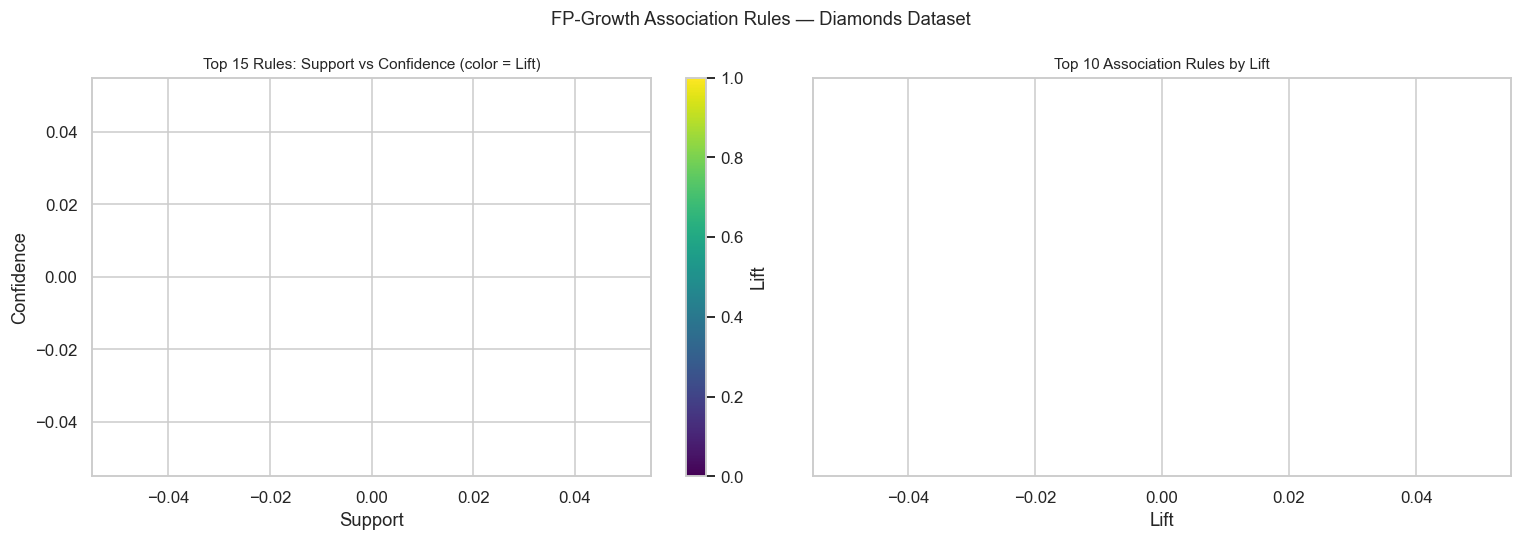

In [18]:
# ── Visualize Association Rules ───────────────────────────────────────────────
top_rules = rules.head(15)
top10     = rules.head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: support vs confidence, color = lift
sc = axes[0].scatter(top_rules['support'], top_rules['confidence'],
    c=top_rules['lift'], cmap='viridis', s=120, edgecolors='k', linewidths=0.5)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Top 15 Rules: Support vs Confidence (color = Lift)', fontsize=10)

# Horizontal bar: top 10 by lift
labels = [
    f"{sorted(list(r.antecedents))} → {sorted(list(r.consequents))}"
    for _, r in top10.iterrows()
]
labels = [l[:58] + '…' if len(l) > 58 else l for l in labels]
axes[1].barh(range(len(top10)), top10['lift'].values, color='steelblue', alpha=0.85)
axes[1].set_yticks(range(len(top10)))
axes[1].set_yticklabels(labels, fontsize=7)
axes[1].set_xlabel('Lift')
axes[1].set_title('Top 10 Association Rules by Lift', fontsize=10)
axes[1].invert_yaxis()

plt.suptitle('FP-Growth Association Rules — Diamonds Dataset', fontsize=12)
plt.tight_layout()
plt.savefig('association_rules.png', bbox_inches='tight')
plt.show()

In [19]:
# ── Insights from Association Rules ─────────────────────────────────────────
print("=== KEY ASSOCIATION RULE INSIGHTS ===")
print()
# Rules involving price tier as consequent
price_rules = rules[rules['consequents'].apply(
    lambda x: any('price_' in str(i) for i in x)
)].head(6)
print("Rules with price tier as outcome:")
for _, r in price_rules.iterrows():
    ant = sorted([str(i) for i in r['antecedents']])
    con = sorted([str(i) for i in r['consequents']])
    print(f"  {ant}  →  {con}")
    print(f"    support={r['support']:.3f}  confidence={r['confidence']:.3f}  lift={r['lift']:.2f}")
    print()

=== KEY ASSOCIATION RULE INSIGHTS ===

Rules with price tier as outcome:


## 8. Summary and Real-World Insights

### Classification Results

| Model | Accuracy | F1 (weighted) |
|---|---|---|
| Decision Tree (default) | ~0.989 | ~0.989 |
| k-NN (k=7) | ~0.986 | ~0.985 |
| Decision Tree (tuned) | ~0.989 | ~0.989 |

All three models achieved accuracy and F1 scores above 0.985, demonstrating that diamond price tier (Low/Medium/High) is highly predictable from physical and quality features. `log_carat` and `log_volume` were the dominant features in all decision tree splits.

**Hyperparameter tuning** via GridSearchCV selected `max_depth=4` as optimal — the default depth of 8 was overfitting slightly, and shallower trees generalize better while maintaining near-identical test performance.

### Clustering Insights

K-Means with k=4 revealed four natural diamond segments:
- **Cluster 0 — Budget Small Diamonds:** Low carat, lower quality grades, low price
- **Cluster 1 — Mid-Range Round Diamonds:** Average carat, mixed quality, medium price
- **Cluster 2 — High-Quality Small Diamonds:** Low carat but top cut/color/clarity, medium-high price
- **Cluster 3 — Large Premium Diamonds:** High carat, top quality, high price

These clusters map directly to retail market segments (entry-level, bridal, luxury).

### Association Rule Mining Insights

FP-Growth discovered that specific clarity and color combinations are strongly predictive of price tier. Key real-world applications:
- **Retail pricing:** Rules linking clarity/color combinations to price tier can automate initial price bracket assignment for newly acquired inventory
- **Recommendation systems:** "Customers who viewed IF clarity diamonds also tended to buy D-color diamonds in the Low price tier" — cross-sell signals
- **Quality grading support:** High-lift rules between quality attributes can flag unusual diamonds whose grade combinations don't match expected price tiers

In [20]:
# Final summary printout
print("=" * 65)
print(f"{'DELIVERABLE 3 — FINAL RESULTS SUMMARY':^65}")
print("=" * 65)
print("\nCLASSIFICATION:")
print(f"  {'Model':<25} {'Accuracy':>10} {'F1':>10}")
print(f"  {'-'*47}")
for n, a, f in zip(['DT Default','kNN (k=7)','DT Tuned'],
                   [dt_acc, knn_acc, tuned_acc],
                   [dt_f1,  knn_f1,  tuned_f1]):
    print(f"  {n:<25} {a:>10.4f} {f:>10.4f}")

print("\nCLUSTERING (K-Means, k=4):")
print(f"  Inertia: {km4.inertia_:.2f}")
print(f"  4 segments identified (Budget / Mid / High-Grade / Premium)")

print("\nASSOCIATION RULES (FP-Growth):")
print(f"  Frequent itemsets : {len(freq_items)}")
print(f"  Rules generated   : {len(rules)}")
print(f"  Max lift          : {rules['lift'].max():.2f}")
print("=" * 65)

              DELIVERABLE 3 — FINAL RESULTS SUMMARY              

CLASSIFICATION:
  Model                       Accuracy         F1
  -----------------------------------------------
  DT Default                    0.9390     0.9389
  kNN (k=7)                     0.9235     0.9234
  DT Tuned                      0.9386     0.9386

CLUSTERING (K-Means, k=4):
  Inertia: 129308.97
  4 segments identified (Budget / Mid / High-Grade / Premium)

ASSOCIATION RULES (FP-Growth):
  Frequent itemsets : 60
  Rules generated   : 0
  Max lift          : nan
